# TRFlearn — a categorical-event TRF pipeline, step by step

A round trip on **categorical event data** (discrete onsets rather than a continuous
stimulus), one subject, entirely with the public `trflearn.simulation` API:
`ExperimentDesign` samples event onsets, `CompoundKernel` supplies the ground-truth
impulse response for each event type, and `EEGSimulator` convolves them into a
continuous signal — exactly the steps in [`01_simulation`](../01_simulation/).

To also exercise TRFlearn's montage-based plots (topomaps, `plot_joint`), each kernel
is given a scalp topography (`make_info`, `gaussian_topography`,
`spatiotemporal_kernel`) and `simulate` turns the events into a multichannel
recording. Everything else stays inline in this notebook — there is no example-only
helper script to look into.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import mne; mne.set_log_level("ERROR")

from trflearn import TRFData, TRFModel
from trflearn.simulation import (
    ExperimentDesign, EEGSimulator, CompoundKernel, GroundTruth,
    build_uniform_isi_sampler, make_info, gaussian_topography,
    spatiotemporal_kernel, simulate,
)

SR = 256
WINDOW = (-0.1, 0.5)
print("sample rate:", SR, "Hz   |   default window:", WINDOW, "s")

sample rate: 256 Hz   |   default window: (-0.1, 0.5) s


## 1 · The data — the round trip from `01_simulation`

An `ExperimentDesign` cycles `stimulus`/`response` events with a uniform ISI; each
gets its own `CompoundKernel` ground-truth impulse response.

In [2]:
design = ExperimentDesign(
    n_events=20000,
    event_types=["stimulus", "response"],
    sfreq=SR,
    duration_s=3000,
    isi_sampler=build_uniform_isi_sampler(
        width=256, offset=640, rng=np.random.default_rng(0)),
    seed=0,
)
events_df = design.generate_events()
features = design.generate_features()
print("stimulus:", features["stimulus"].shape, " | response:", features["response"].shape)

stimulus: (768000, 1)  | response: (768000, 1)


In [3]:
stim_kernel = (CompoundKernel("stimulus", sfreq=SR)
               .add(peak_latency=0.10, amplitude=5.0, width=0.03)
               .add(peak_latency=0.20, amplitude=-3.0, width=0.05))

resp_kernel = (CompoundKernel("response", sfreq=SR)
               .add(peak_latency=0.05, amplitude=4.0, width=0.02))

`EEGSimulator` convolves each kernel with its event's stick function and sums
them into a single continuous channel — `plot_simulation_kernels` shows the
injected kernels, an EEG snippet with event markers, the ISI histogram and the PSD.

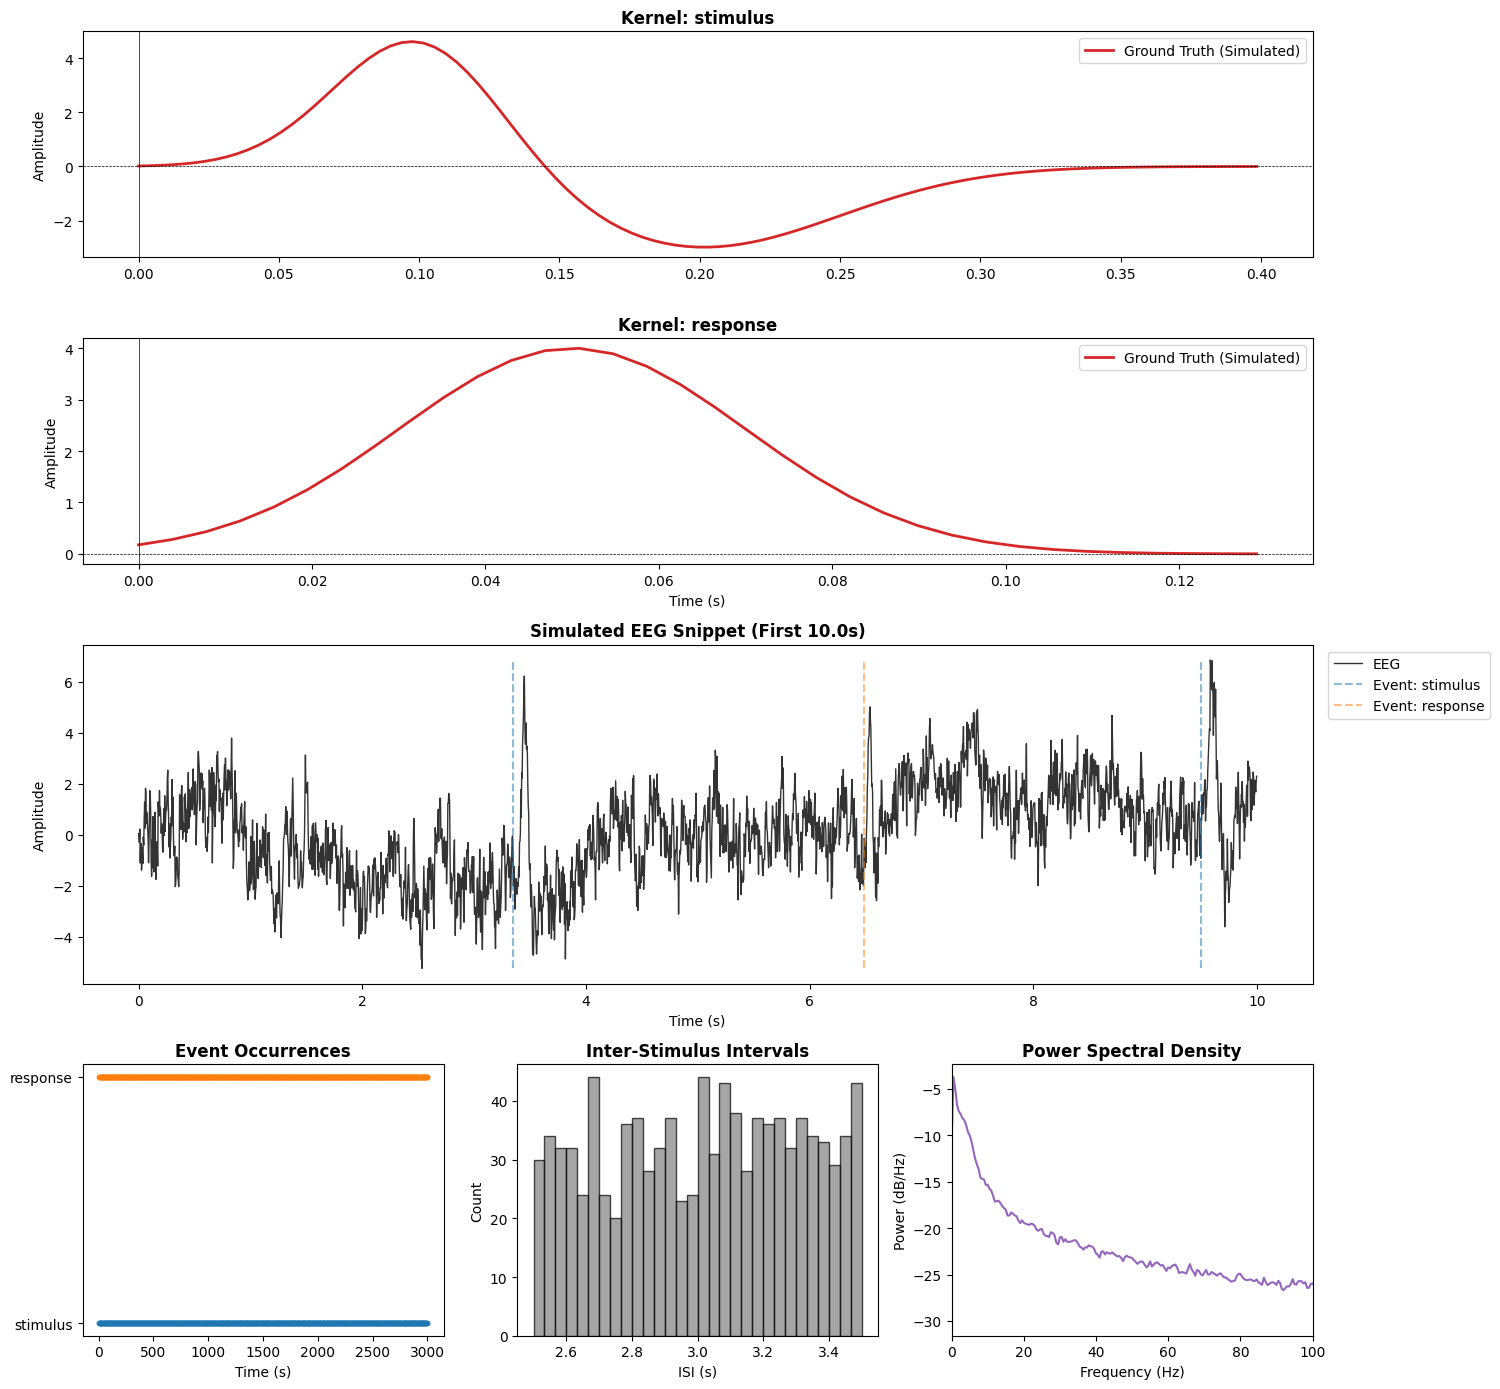

In [4]:
simulator = EEGSimulator(sfreq=SR, duration=300)
simulator.add_kernel(stim_kernel, activation=lambda row: row["type"] == "stimulus")
simulator.add_kernel(resp_kernel, activation=lambda row: row["type"] == "response")
simulator.set_events(events_df)
simulator.simulate()
simulator.add_noise(colour="pink", scale=1.6, rng=np.random.default_rng(0))
simulator.plot_simulation_kernels(show=True);

## 2 · Ground truth kernels + a scalp topography

`EEGSimulator` itself simulates one channel. To also exercise TRFlearn's montage-based
plots, `gaussian_topography` gives each kernel a plausible scalp distribution —
posterior for the (sensory) `stimulus` response, fronto-central for the (motor)
`response`. The topography alone is just a spatial weighting; the actual ground truth is
the kernel's waveform *times* its topography, which `spatiotemporal_kernel` builds in
the layout of a fitted model's `coef_` — `(channels, sub-features, delays)`.

A `GroundTruth` holds those kernels and draws them with the model's own figures, so
the `plot_joint` below is the same figure section 5's model draws.

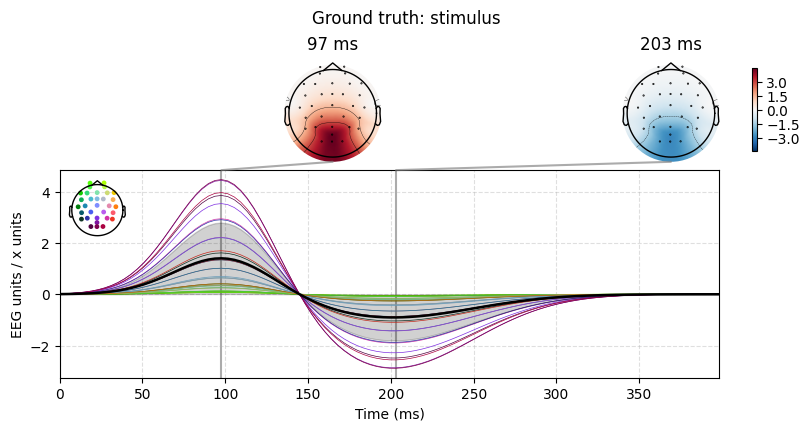

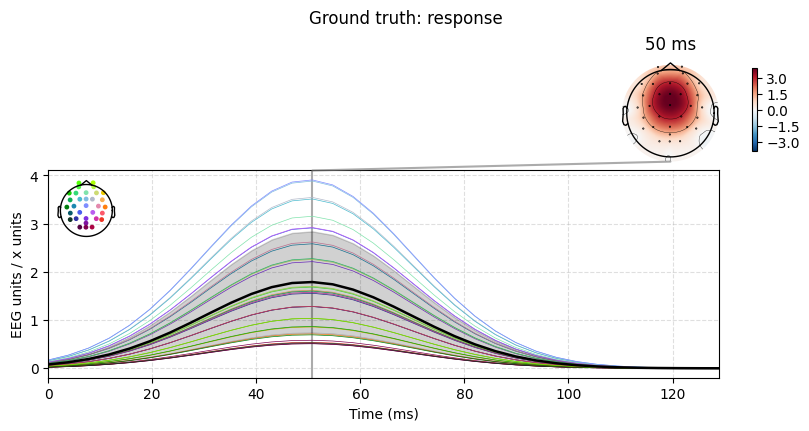

In [5]:
CH_NAMES = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2",
           "FC6", "T7", "C3", "Cz", "C4", "T8", "CP5", "CP1", "CP2", "CP6",
           "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2", "AF3",
           "AF4", "FCz"]
info = make_info(CH_NAMES, sfreq=SR)
stim_topo = gaussian_topography(info, center=[0, -0.6, 0.6])   # posterior (sensory)
resp_topo = gaussian_topography(info, center=[0, 0.3, 0.9])    # fronto-central (motor)

KERNELS = {
    "stimulus": spatiotemporal_kernel(stim_kernel.waveform, stim_topo),
    "response": spatiotemporal_kernel(resp_kernel.waveform, resp_topo),
}
truth = GroundTruth(KERNELS, SR, info=info)
truth.plot_joint("stimulus", show=True)
truth.plot_joint("response", show=True);

## 3 · A montage-carrying recording

Repeating the round trip above for a few independent segments (each with its own
events) and handing their impulse trains to `simulate` gives a multi-channel,
multi-segment recording — the same shape `TRFData` expects from a real multi-run
subject. `simulate` convolves each feature with its kernel, adds pink noise
independently per channel at the requested signal-to-noise ratio, and returns the
`TRFData` to model together with the `GroundTruth` it should recover.

In [6]:
def segment_features(seed, duration_s):
    """One segment's impulse trains, from its own events."""
    seg_design = ExperimentDesign(
        n_events=int(2 * duration_s / 3), event_types=["stimulus", "response"],
        sfreq=SR, duration_s=duration_s,
        isi_sampler=build_uniform_isi_sampler(
            width=256, offset=640, rng=np.random.default_rng(seed)),
        seed=seed,
    )
    return seg_design.generate_features(seg_design.generate_events())


segments = [segment_features(seed, duration_s=150) for seed in (42, 43, 44)]
features = {name: [seg[name] for seg in segments] for name in ("stimulus", "response")}

# noise at 0.6x the signal's standard deviation: 20·log10(1/0.6) ≈ 4.4 dB
data, truth = simulate(features, KERNELS, SR, info=info, snr_db=4.4,
                       noise_colour="pink", rng=42)
print("segments:", len(data.raw_targets), " | shape each:", data.raw_targets[0].shape,
      "(samples × chans)")

segments: 3  | shape each: (38400, 32) (samples × chans)


## 4 · The `TRFData` container and the CV split

`simulate` already returned the container, with the montage attached. `TRFData` is
window-agnostic and lazy — the delay window lives on the *model*. You pick how folds
are formed with `create_partitions`; here each recording segment is its own fold
(`segments_as_folds=True`). Other options: `n_folds=5`, `stratify_by_segment=True`, or
a single contiguous `train_size=0.8` split.

In [7]:
data.create_partitions(segments_as_folds=True)   # lazy: recorded now, folds built at materialize
print("montage carried:", data.info is not None, " | segments:", len(data.raw_targets))

montage carried: True  | segments: 3


## 5 · Perform simple grid search cross validation

`TRFModel(cv="pooled")` (the default) runs standard k-fold: for each fold, one model is fit on the pooled complement and predicts the held-out set, picking the ridge penalty `λ` on an inner train/validation split via `gridsearchCV`.

In [8]:
model = TRFModel(TRFDataset=data, features=["stimulus", "response"],
                 default_window=WINDOW, solver="ridge")
best_regularization, (trfs, corr) = model.gridsearchCV(
    regularization_grid=np.logspace(-2, 5, 20), validation_plot=False, run_fit=True)
print(f"pooled: λ={best_regularization:.3g}  mean test r={float(corr.mean()):.3f}")

pooled: α=0.127  mean test r=0.733


## 6 · Without a montage

If the targets are plain arrays with no channel info, there is no channel layout. The
container's `raw_features` and `raw_targets` hand back the inputs as arrays, which is
how this section rebuilds the same recording without its montage. The figures that draw
one trace per channel still work, naming the channels `Target 0`, `Target 1`, and so on;
the ones that draw a head raise a clear error saying what is missing.

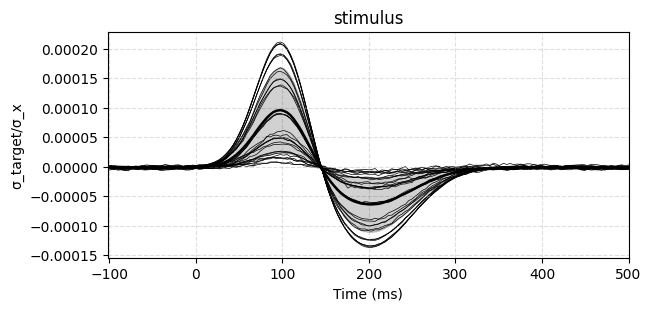

plot_joint without montage -> plot_joint draws topomaps, which need sensor positions, and there is no channel info. Give the data a montage: TRFData.set_montage, or an mne.Raw that carries one. plot, plot_image, plot_psd and plot_average work without them.


In [9]:
arr_data = TRFData(features={"stimulus": data.raw_features["stimulus"]},
                   y=data.raw_targets, sample_rate=SR)
arr_data.create_partitions(n_folds=4)
arr_model = TRFModel(TRFDataset=arr_data, features=["stimulus"], default_window=WINDOW)
arr_model.fit(regularization=1e3)
arr_model.plot("stimulus", show=True)   # one trace per channel: no positions needed

try:
    arr_model.plot_joint("stimulus")
except RuntimeError as e:
    print("plot_joint without montage ->", e)

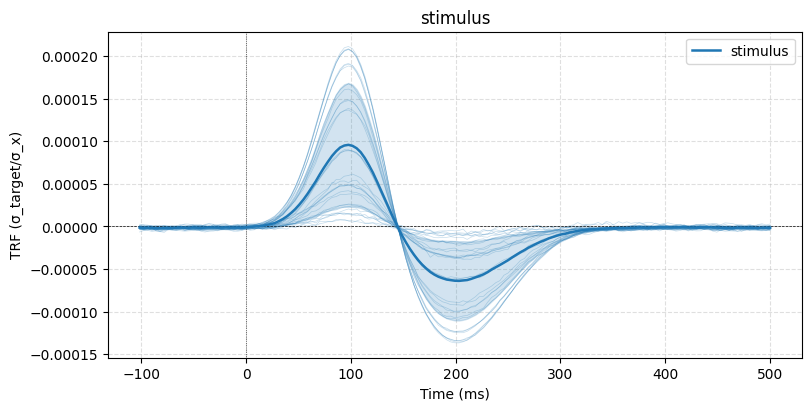

In [10]:
arr_model.plot_average("stimulus")

## 7 · Inspecting the model

Every plot is an on-demand method on the fitted `model`. `validation_plot` shows the λ search and the λ-coloured TRFs; `plot_average` gives a butterfly + channel mean/std for a feature (no montage needed).

**`validation_plot`** — the λ search and the λ-coloured TRFs.

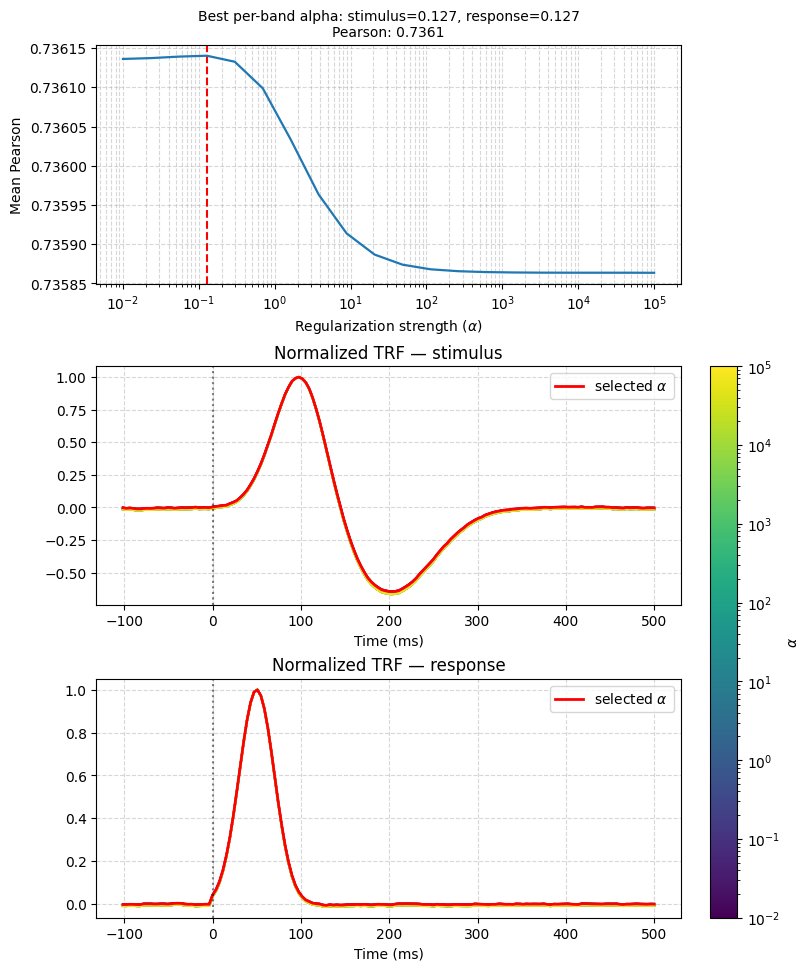

In [11]:
model.validation_plot()

**`plot_average`** — butterfly + channel mean/std for each event type (no montage needed).

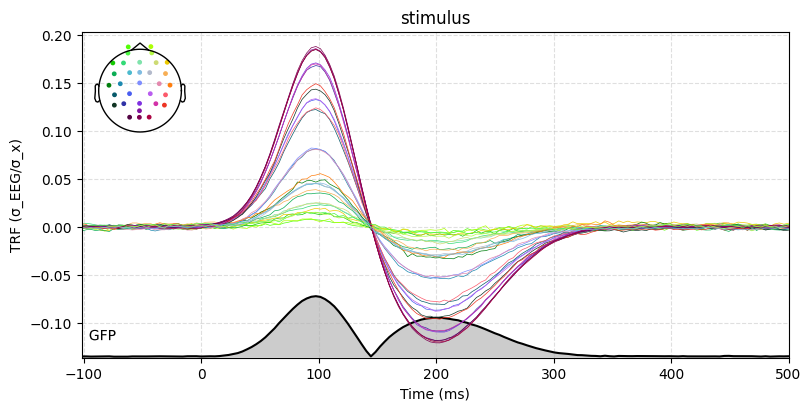

In [12]:
model.plot_average("stimulus")

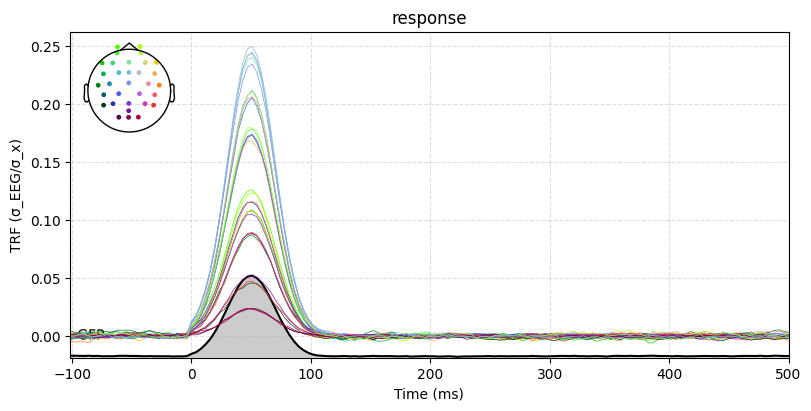

In [13]:
model.plot_average("response")

---
That is the whole workflow: `ExperimentDesign` + `CompoundKernel` + `EEGSimulator`
(the `01_simulation` round trip) → give each kernel a topography with
`spatiotemporal_kernel` → `simulate` → `TRFData` → `create_partitions` →
`TRFModel(cv=…)` → `gridsearchCV`/`fit` → plots — the same recipe as
[`02_auditory_pipeline`](../02_auditory_pipeline/), applied to categorical event
regressors instead of a continuous stimulus, and built only from the public
`trflearn.simulation` and `trflearn` APIs.